In [ ]:
# Imports and utilities
import numpy as np
import random
import math
import matplotlib.pyplot as plt

##Class GridMap defines a grid of nxn. Start point is (0,0). Goal is (n-1,n-1).

In [ ]:
class Gridworld:
    def __init__(self, size=5, stochastic=False, slip_prob=0.0):
        self.size = size
        self.start = (0, 0)
        self.goal = (size-1, size-1)
        self.state = self.start
        self.n_actions = 4  # up, right, down, left
        self.action_map = {
            0: (-1, 0),
            1: (0, 1),
            2: (1, 0),
            3: (0, -1)
        }
        self.stochastic = stochastic
        self.slip_prob = slip_prob
    
    # Add a function reset() to Class GridMap to bring agent back to start.
    def reset(self):
        self.state = self.start
        return self.state
    
    def step(self, action):
        action = random.randint(0, self.n_actions-1)
        dr, dc = self.action_map[action]
        r, c = self.state
        nr, nc = r + dr, c + dc
        # Keep within bounds
        nr = max(0, min(self.size-1, nr))
        nc = max(0, min(self.size-1, nc))
        self.state = (nr, nc)
        done = (self.state == self.goal)
        reward = 0 if done else -1
        return self.state, reward, done, {}

    def render_gridmap(env, steps_so_far=0, reward_last_step=None, show=True):
        size = env.size
        start = env.start
        goal = env.goal
        r, c = env.state
    
        fig, ax = plt.subplots(figsize=(size, size))
        ax.set_title("Gridmap", fontsize=14)
    
        # Draw grid cells
        for i in range(size):
            for j in range(size):
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=1)
                ax.add_patch(rect)
    
        # Highlight start, goal, and current state
        # Start cell
        ax.add_patch(plt.Rectangle((start[1], start[0]), 1, 1, facecolor='#B3E5FC', alpha=0.5, edgecolor='black'))
        ax.text(start[1] + 0.5, start[0] + 0.5, "S", va='center', ha='center', fontsize=12, weight='bold')
    
        # Goal cell
        ax.add_patch(plt.Rectangle((goal[1], goal[0]), 1, 1, facecolor='#C8E6C9', alpha=0.6, edgecolor='black'))
        ax.text(goal[1] + 0.5, goal[0] + 0.5, "G", va='center', ha='center', fontsize=12, weight='bold')
    
        # Current position
        ax.add_patch(plt.Circle((c + 0.5, r + 0.5), 0.3, color='#FF7043', alpha=0.9))
        ax.text(c + 0.5, r + 0.5, "O", va='center', ha='center', fontsize=14, color='white', weight='bold')
    
        # Axes formatting
        ax.set_xlim(0, size)
        ax.set_ylim(size, 0) 
        ax.set_xticks(range(size))
        ax.set_yticks(range(size))
        ax.set_xticklabels(range(size))
        ax.set_yticklabels(range(size))
        ax.set_aspect('equal')
        ax.grid(False)
    
        # Text panel: episode info
        info_lines = [
            f"Current position: {env.state}",
            f"Goal position: {env.goal}",
            f"Current length (steps): {int(steps_so_far)}",
            f"Last reward: {reward_last_step if reward_last_step is not None else 'N/A'}",
            f"Stochastic: {env.stochastic} (slip_prob={env.slip_prob})"
        ]
        info_text = "\n".join(info_lines)
        fig.subplots_adjust(right=0.75)
        
        fig.text(0.73, 0.5, info_text, va='center', ha='left',
                 fontsize=11, bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
     
    
        if show:
            plt.show()
        return fig, ax

In [ ]:
#Demo start
env = Gridworld(size=5)
s0 = env.reset()
steps = 0
reward = None
env.render_gridmap(steps_so_far=steps, reward_last_step=reward)
print("Start state:", s0)

In [ ]:
#Demo a step
s1, reward, done, info = env.step(1)  # move right
steps += 1
print("Next:", s1, reward, done)
env.render_gridmap(steps_so_far=steps, reward_last_step=reward)

Add a function reset() to Class GridMap to bring agent back to start.

Add a function run_random_agent that takes random steps until the goal is reached. Function signature : run_random_agent(env, max_steps). Should return Final Reward (Accumulated) and Steps Taken.

In [ ]:
def run_random_agent(env, max_steps, render=False):
    state = env.reset()
    total_reward = 0
    steps = 0
    done = False
    path = [(state, None)]  # Track path for heatmap
    
    while not done and steps < max_steps:
        action = random.randint(0, env.n_actions - 1)
        state, reward, done, info = env.step(action)
        total_reward += reward
        steps += 1
        path.append((state, reward))
        
        if render:
            env.render_gridmap(steps_so_far=steps, reward_last_step=reward)
    
    return total_reward, steps, path

Modify function run_random_agent to run N consecutive runs.

In [ ]:
def run_random_agent_modified(env, max_steps, N):
    rewards = []
    all_paths = []
    
    for episode in range(N):
        total_reward, steps, path = run_random_agent(env, max_steps, render=False)
        rewards.append(total_reward)
        all_paths.extend(path)
        print(f"Episode {episode + 1}: {steps} steps, reward {total_reward}")
    
    return rewards, all_paths

Plot moving average of Reward (window size=50 or 25 or 10)

In [ ]:
# Plot moving average of Reward (window size=50 or 25 or 10)
def plot_moving_average(rewards, window_size=50):
    cumsum = np.cumsum(np.insert(rewards, 0, 0)) 
    moving_avg = (cumsum[window_size:] - cumsum[:-window_size]) / window_size

    plt.figure(figsize=(10, 5))
    plt.plot(moving_avg)
    plt.title(f'Moving Average of Rewards (window size={window_size})')
    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.grid()
    plt.show()

Add a function visualize_heatmap to visualize the paths taken (over multiple runs using run_random_agent) as a heatmap on the grid (a cell that is traversed more == higher on the colour scale)

In [58]:
# Add a function visualize_heatmap to visualize the paths taken (over multiple runs using run_random_agent) as a heatmap on the grid (a cell that is traversed more == higher on the colour scale)
def visualize_heatmap(env, path_counts):
    size = env.size
    heatmap = np.zeros((size, size))

    for (r, c), count in path_counts.items():
        heatmap[r, c] = count

    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Number of Visits')
    plt.title('Heatmap of Agent Paths')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.show()

Modify render_gridmap to make a GIF visualization of a single complete run

In [ ]:
# Modify render_gridmap to make a GIF visualization of a single complete run
import imageio

def render_gridmap_gif(env, path, save_path='gridmap_run.gif'):
    size = env.size
    images = []

    for step_num, (state, reward) in enumerate(path):
        r, c = state

        fig, ax = plt.subplots(figsize=(size, size))
        ax.set_title("Gridmap", fontsize=14)

        # Draw grid cells
        for i in range(size):
            for j in range(size):
                rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=1)
                ax.add_patch(rect)

        # Start cell
        ax.add_patch(plt.Rectangle((env.start[1], env.start[0]), 1, 1, facecolor='#B3E5FC', alpha=0.5, edgecolor='black'))
        ax.text(env.start[1] + 0.5, env.start[0] + 0.5, "S", va='center', ha='center', fontsize=12, weight='bold')

        # Goal cell
        ax.add_patch(plt.Rectangle((env.goal[1], env.goal[0]), 1, 1, facecolor='#C8E6C9', alpha=0.6, edgecolor='black'))
        ax.text(env.goal[1] + 0.5, env.goal[0] + 0.5, "G", va='center', ha='center', fontsize=12, weight='bold')

        # Current position
        ax.add_patch(plt.Circle((c + 0.5, r + 0.5), 0.3, color='#FF7043', alpha=0.9))
        ax.text(c + 0.5, r + 0.5, "O", va='center', ha='center', fontsize=14, color='white', weight='bold')

        # Axes formatting
        ax.set_xlim(0, size)
        ax.set_ylim(size, 0) 
        ax.set_xticks(range(size))
        ax.set_yticks(range(size))
        ax.set_xticklabels(range(size))
        ax.set_yticklabels(range(size))
        ax.set_aspect('equal')
        ax.grid(False)

        # Text panel: episode info
        info_lines = [
            f"Current position: {state}",
            f"Goal position: {env.goal}",
            f"Current length (steps): {step_num}",
            f"Last reward: {reward if reward is not None else 'N/A'}",
            f"Stochastic: {env.stochastic} (slip_prob={env.slip_prob})"
        ]
        info_text = "\n".join(info_lines)    
        fig.subplots_adjust(right=0.75)
        fig.text(0.73, 0.5, info_text, va='center', ha='left',
                 fontsize=11, bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
        
        # Save frame to images - FIXED
        fig.canvas.draw()
        image = np.array(fig.canvas.renderer.buffer_rgba())
        images.append(image[:, :, :3])  # Remove alpha channel
        plt.close(fig)  # Close figure to avoid display
    
    # Save as GIF
    imageio.mimsave(save_path, images, duration=0.3)
    print(f"GIF saved to {save_path}")

Episode 1: 185 steps, reward -184
Episode 2: 263 steps, reward -262
Episode 3: 103 steps, reward -102
Episode 4: 87 steps, reward -86
Episode 5: 139 steps, reward -138
Episode 6: 63 steps, reward -62
Episode 7: 45 steps, reward -44
Episode 8: 377 steps, reward -376
Episode 9: 149 steps, reward -148
Episode 10: 128 steps, reward -127
Episode 11: 374 steps, reward -373
Episode 12: 147 steps, reward -146
Episode 13: 80 steps, reward -79
Episode 14: 127 steps, reward -126
Episode 15: 23 steps, reward -22
Episode 16: 74 steps, reward -73
Episode 17: 154 steps, reward -153
Episode 18: 71 steps, reward -70
Episode 19: 10 steps, reward -9
Episode 20: 15 steps, reward -14
Episode 21: 142 steps, reward -141
Episode 22: 303 steps, reward -302
Episode 23: 47 steps, reward -46
Episode 24: 53 steps, reward -52
Episode 25: 115 steps, reward -114
Episode 26: 77 steps, reward -76
Episode 27: 112 steps, reward -111
Episode 28: 37 steps, reward -36
Episode 29: 46 steps, reward -45
Episode 30: 196 steps, 

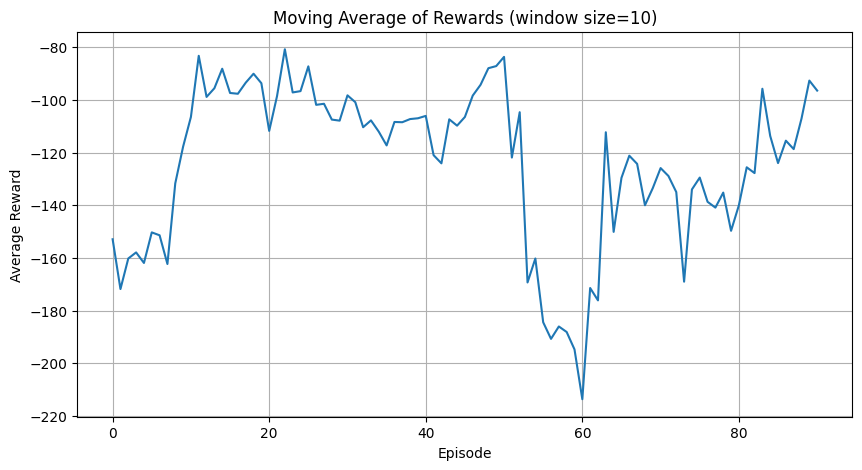

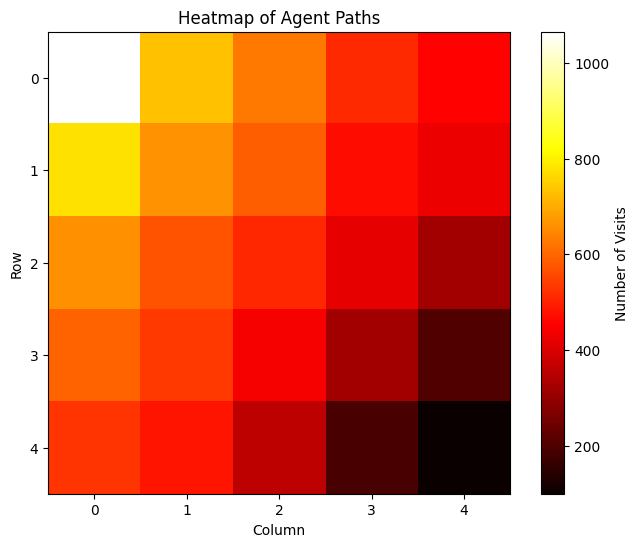

GIF saved to gridmap_run.gif


In [59]:
env = Gridworld(size=5)
rewards, all_paths = run_random_agent_modified(env, max_steps=1000, N=100)

# Plot moving average
plot_moving_average(rewards, window_size=10)

# Create heatmap
from collections import Counter
path_counts = Counter([state for state, _ in all_paths])
visualize_heatmap(env, path_counts)

# Create GIF for a SINGLE episode
env_gif = Gridworld(size=5)
_, _, single_path = run_random_agent(env_gif, max_steps=1000, render=False)
render_gridmap_gif(env_gif, single_path, save_path='gridmap_run.gif')